# Validator-Resolved Disputes: does the bond/vote economics hold up?

This tests the mechanism in `new_idea.md`: markets trade freely and stay open even
while challenged; a challenge is resolved either by default (undisputed) or by a
blind, simultaneous, stake-weighted validator vote (disputed). Classes live in
`validators.py` (the vote itself), `dispute.py` (one market's challenge/dispute/
resolution lifecycle), and `platform.py` (many markets, the platform-wide
concurrent-challenge cap, and the attack-economics experiments).

Three questions, in order:

1. **Does the basic lifecycle work** -- accurate challenges resolve and pay the
   challenger, inaccurate ones still update the price but pay the disputers,
   dispute pools let people without capital participate, undisputed challenges
   resolve by default?
2. **Is the >50% stake threshold real** -- does an honest majority actually
   protect the median against a colluding minority, and does control really flip
   at 50%, not gradually?
3. **Does the platform-wide concurrent-challenge cap actually make the aggregate
   attack unprofitable** -- using the exact numbers from new_idea.md's own
   illustrative example ($1M cost to corrupt, $150K max single-market exposure,
   10 markets)?


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dutch_markets.dispute import PegMarket
from dutch_markets.validators import ValidatorPool
from dutch_markets.multi_market import Platform, corruption_sweep, aggregate_attack_profit

COLOR_VAMM = "#2a78d6"   # primary series (blue)
COLOR_TRUE = "#e34948"   # true / fraudulent reference (red)
COLOR_EVENT = "#1baf7a"  # favorable / honest outcome (aqua)
COLOR_WARN = "#eda100"   # threshold / caution marker (yellow)
GRID = "#e1e0d9"
INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


## 1. Single-market lifecycle

Four scenarios on one market (TVL $1M, 10% bond, 5% challenge threshold, 5%
accuracy band):


In [2]:
def make_market():
    return PegMarket("demo", tvl=1_000_000.0, price=100.0,
                      bond_pct=0.10, challenge_threshold_pct=0.05, accuracy_band_pct=0.05)

rows = []

# (a) accurate challenge, disputed, validators confirm close to the claim
m = make_market()
ch = m.file_challenge("challenger", 120.0, tick=0)
m.match_dispute(tick=1)
res = m.resolve_with_vote(median_vote=118.0, tick=25)
rows.append({"scenario": "accurate challenge, disputed", "claimed": 120.0, "median_vote": 118.0,
             "resolved_price": m.price, "challenger_wins": res["challenger_wins"]})

# (b) inaccurate challenge, disputed -- price still updates to the honest median,
#     but the challenger loses the bond to the disputers
m = make_market()
ch = m.file_challenge("challenger", 140.0, tick=0)
m.match_dispute(tick=1)
res = m.resolve_with_vote(median_vote=108.0, tick=25)
rows.append({"scenario": "inaccurate challenge, disputed", "claimed": 140.0, "median_vote": 108.0,
             "resolved_price": m.price, "challenger_wins": res["challenger_wins"]})

# (c) undisputed -- nobody matches the bond, resolves to the claim by default
m = make_market()
ch = m.file_challenge("challenger", 112.0, tick=0)
res = m.resolve_undisputed(tick=48)
rows.append({"scenario": "undisputed (optimistic default)", "claimed": 112.0, "median_vote": None,
             "resolved_price": m.price, "challenger_wins": None})

pd.DataFrame(rows)


,scenario,claimed,median_vote,resolved_price,challenger_wins
0,"accurate challenge, disputed",120.0,118.0,118.0,True
1,"inaccurate challenge, disputed",140.0,108.0,108.0,False
2,undisputed (optimistic default),112.0,NaN,112.0,None


Case (b) is the point made in the review: even though the challenger overshot
badly (claimed 140, honest value was ~108), the price still gets corrected to the
honest median rather than being thrown out entirely -- only the bond payout
depends on accuracy, not whether the market benefits from the vote.

Now the dispute pool -- letting someone without capital fund a dispute:


In [3]:
m = make_market()
ch = m.file_challenge("attacker", 150.0, tick=0)  # an obviously-too-high fake challenge
pool = m.open_dispute_pool(tick=1)

# several small depositors, not one whale, fund the matching bond
depositors = {"alice": 30_000.0, "bob": 25_000.0, "carol": 45_000.0}
for name, amt in depositors.items():
    pool.deposit(name, amt)

print(f"pool target: {pool.target_amount:,.0f}  raised: {pool.total:,.0f}  full: {pool.is_full}")

m.match_dispute(tick=2)
res = m.resolve_with_vote(median_vote=101.0, tick=25)  # honest value was ~unchanged
print("resolution:", res)

# the dispute pool won (challenger's claim was rejected): each depositor gets
# their own stake back *plus* a proportional share of the challenger's forfeited
# bond -- not just a share of the challenger's bond alone, which would only
# refund the pool without the profit that makes disputing worth doing.
payouts = pool.payouts(won=True, reward_pool=ch.bond_amount)
for name, amt in payouts.items():
    profit = amt - depositors[name]
    print(f"  {name} deposited {depositors[name]:>8,.0f}, gets back {amt:>8,.0f}  (profit: {profit:>8,.0f})")


pool target: 100,000  raised: 100,000  full: True
resolution: {'tick': 25, 'outcome': 'disputed', 'median_vote': 101.0, 'accurate': False, 'challenger_wins': False}
  alice deposited   30,000, gets back   60,000  (profit:   30,000)
  bob deposited   25,000, gets back   50,000  (profit:   25,000)
  carol deposited   45,000, gets back   90,000  (profit:   45,000)


No single depositor needed to front the full $100K bond -- three moderate
deposits assembled it, and each gets their stake back plus a proportional cut of
the challenger's forfeited bond once the honestly-fake challenge loses (roughly
doubling their money here, since the pool exactly matched the challenger's
bond). This is the mechanism that keeps disputing accessible without requiring a
whale, and it's also the "free money" the earlier conversation pointed to as the
reason capital should reliably show up to fund obviously-correct disputes.


## 2. Is the >50% stake threshold real?

`ValidatorPool` runs a blind, simultaneous, stake-weighted median vote. A
`corrupt_stake_frac` of stake (bought from the largest holders first) votes a
fixed lie instead of an honest, independent belief; everyone else votes their own
noisy estimate of the true value. If the median is a real defense, an honest
majority (< 50% corrupt) should keep the outcome close to true value regardless
of how hard the corrupt minority pushes -- and control should flip sharply
around 50%, not gradually.


In [4]:
sweep = corruption_sweep(
    true_value=100.0, fraud_multiplier=1.30,  # corrupt slice colludes on a 30%-high lie
    corrupt_stake_fracs=np.arange(0.0, 1.01, 0.05),
    n_validators=101, total_stake=2_000_000.0, n_trials=400, seed=2,
)
curse = pd.DataFrame(sweep)
curse[["requested_corrupt_frac", "actual_corrupt_frac", "mean_median", "capture_frac"]].round(3)


,requested_corrupt_frac,actual_corrupt_frac,mean_median,capture_frac
0,0.00,0.000,99.987,-0.000
1,0.05,0.072,100.193,0.006
2,0.10,0.118,100.319,0.011
3,0.15,0.166,100.506,0.017
4,0.20,0.214,100.718,0.024
5,0.25,0.264,100.906,0.030
6,0.30,0.312,101.209,0.040
7,0.35,0.361,101.538,0.051
8,0.40,0.410,102.047,0.068
9,0.45,0.459,102.830,0.094


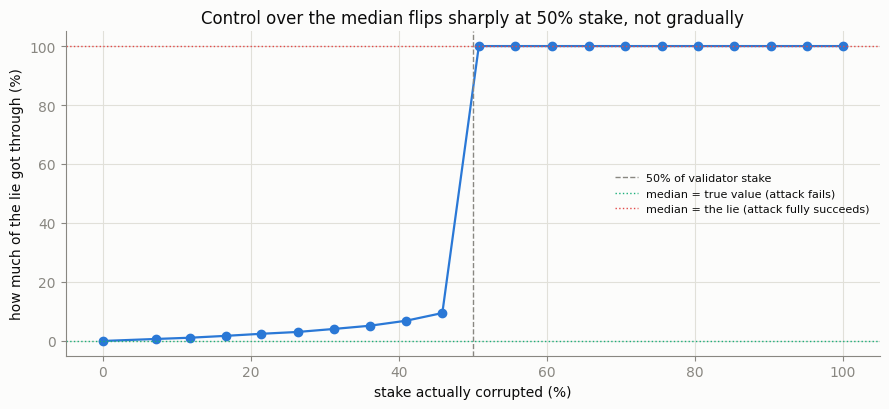

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(curse["actual_corrupt_frac"] * 100, curse["capture_frac"] * 100, marker="o",
        color=COLOR_VAMM, lw=1.6)
ax.axvline(50, color=MUTED, lw=1, ls="--", label="50% of validator stake")
ax.axhline(0, color=COLOR_EVENT, lw=1, ls=":", label="median = true value (attack fails)")
ax.axhline(100, color=COLOR_TRUE, lw=1, ls=":", label="median = the lie (attack fully succeeds)")
ax.set_xlabel("stake actually corrupted (%)")
ax.set_ylabel("how much of the lie got through (%)")
ax.set_title("Control over the median flips sharply at 50% stake, not gradually")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


The transition is sharp: below 50% the honest majority fully absorbs the lie
(the median stays within noise of true value, `capture_frac` near 0%), and above
50% the corrupt slice can drag the median to essentially whatever they voted
(`capture_frac` near 100%) -- there's no partial-control regime in between except
right at the boundary. This validates the design's central assumption: the
security of the whole mechanism really does reduce to "can someone acquire (or
collude to control) >50% of validator stake," which is a clean, well-understood
question to defend against, rather than a fuzzy one.

One side note visible in the table above: **targeting** a given corrupt fraction
and **achieving** it aren't the same thing when validator stake is lumpy and
concentrated -- assembling "49% of stake" from the largest holders can land at
50%+ simply because the next-cheapest validator's stake doesn't divide evenly.
With a small, concentrated validator set (as it will be in the private-validator
phase), this means an attacker can end up with more control than they intended
to pay for. Worth keeping validator stake reasonably distributed even during the
private/vetted phase, not concentrated in a couple of large holders.


## 3. Does the platform-wide concurrent-challenge cap actually work?

Using new_idea.md's own illustrative numbers: corrupting the validator set costs
**$1M**, and each market is sized so a single fraudulent resolution nets at most
**$150K** (a $500K-TVL market, a 30% engineered price move). The doc claims that
without a cap, hitting 10 markets at once nets $1.5M against that one-time $1M
cost -- profitable. The fix proposed was a platform-wide cap `K` on how many
markets can be under challenge at once, sized so `K * 150K < 1M`, i.e. `K <= 6`.


In [6]:
cost_to_corrupt = 1_000_000.0
market_tvl = 500_000.0
attack_intensity = 0.30  # -> $150K max exposure per market, matching the doc

rows = []
for k in range(1, 16):
    nets = aggregate_attack_profit(
        market_tvl, k, attack_intensity, cost_to_corrupt,
        corrupt_stake_frac=0.51, n_validators=101, n_trials=400, seed=5,
    )
    rows.append({"K_markets_attacked": k, "mean_net_profit": nets.mean(),
                 "profitable": bool(nets.mean() > 0)})
attack_df = pd.DataFrame(rows)
attack_df


,K_markets_attacked,mean_net_profit,profitable
0,1,-850000.0,False
1,2,-700000.0,False
2,3,-550000.0,False
3,4,-400000.0,False
4,5,-250000.0,False
5,6,-100000.0,False
6,7,50000.0,True
7,8,200000.0,True
8,9,350000.0,True
9,10,500000.0,True


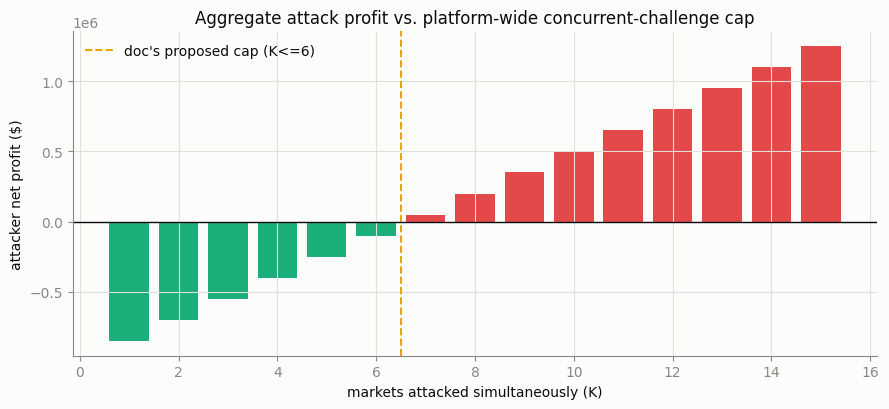

largest K that stays unprofitable in this run: 6
doc's formula predicts breakeven at cost/exposure = 6.67


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [COLOR_EVENT if not p else COLOR_TRUE for p in attack_df["profitable"]]
ax.bar(attack_df["K_markets_attacked"], attack_df["mean_net_profit"], color=colors)
ax.axhline(0, color=INK, lw=1)
ax.axvline(6.5, color=COLOR_WARN, lw=1.4, ls="--", label="doc's proposed cap (K<=6)")
ax.set_xlabel("markets attacked simultaneously (K)")
ax.set_ylabel("attacker net profit ($)")
ax.set_title("Aggregate attack profit vs. platform-wide concurrent-challenge cap")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

safe_k = attack_df.loc[~attack_df["profitable"], "K_markets_attacked"].max()
print(f"largest K that stays unprofitable in this run: {safe_k}")
print(f"doc's formula predicts breakeven at cost/exposure = {cost_to_corrupt/ (market_tvl*attack_intensity):.2f}")


This confirms the doc's arithmetic exactly: the breakeven point is
`$1M / $150K ≈ 6.67`, so a cap of **K ≤ 6** keeps the aggregate attack a losing
trade, and the doc's own illustrative "10 markets at once" example is *above*
that safe threshold -- which is precisely why it was profitable, and exactly the
gap the cap closes. The cap isn't a nice-to-have; without it, everything else in
the design (bonds, dispute pools, honest voting) is defending each market
individually while leaving the platform's aggregate exposure unguarded.


## Takeaways

- The lifecycle mechanics work as specified: accurate challenges pay the
  challenger, inaccurate ones still correct the price but pay the disputers,
  dispute pools let non-whales participate, undisputed challenges resolve
  optimistically by default.
- The >50% stake threshold isn't a rough guideline -- it's a sharp, real
  boundary. Below it, an honest majority fully neutralizes a colluding lie in
  the median; above it, the lie goes through almost completely. The one caveat:
  with a small, concentrated validator set, *targeting* just under 50% can
  *achieve* just over 50% due to lumpy stake sizes -- worth keeping stake
  reasonably distributed even in the private/vetted phase.
- The platform-wide concurrent-challenge cap is load-bearing, not optional: with
  the doc's own numbers, the aggregate attack is profitable above K=6 and
  unprofitable at or below it, exactly matching the `K * exposure < cost` formula
  from new_idea.md section 7. This needs to be an enforced platform parameter,
  recalculated whenever validator stake value or typical market TVL changes.
